## Rapport de TP MPI - Yassine, Yassine & Yannis AULLEN CHOUBRAC

Contexte

Objectif

Description matériaux utilisés

### Etape 1 : calcul du diamètre des fibres

Description méthodologie + matériel

![Tableau des mesures des diamètres des fibres pour chaque méthode](mesure_diametre_tableau.png)

Discussion des méthodes

Remarque fibre carbone, noire => difficulté de mesure + photos

### Etape 2 : expérience pour calculer la contrainte à la rupture

info expérience + photo + présentation matériel


Contrainte à la rupture calculée : 5398.86 MPa
Module de Young calculé : 250.67 GPa


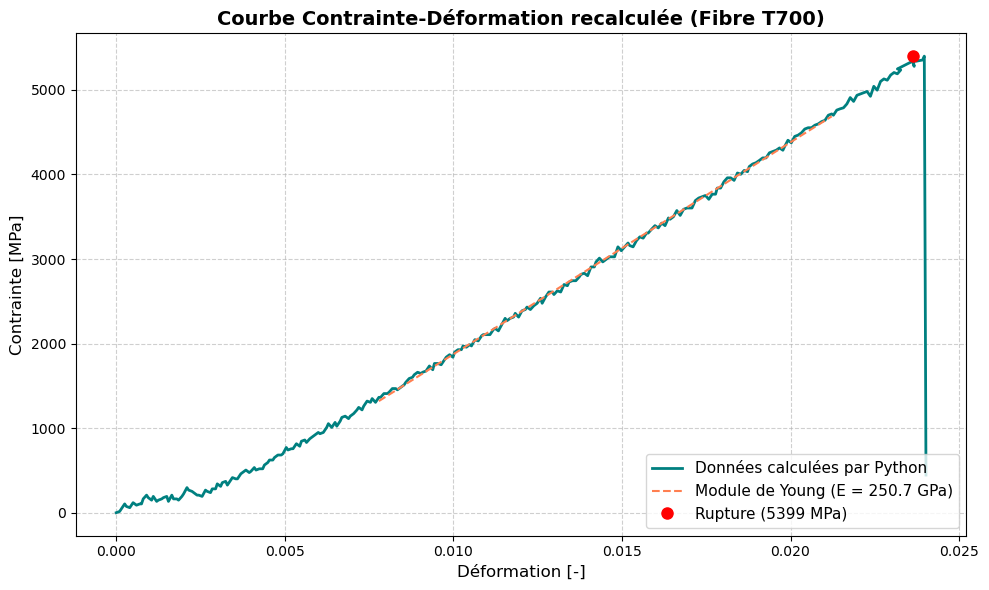

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('donnees_brutes_t700_position_force.csv')

# données de la fibre
diametre_um = 6.49                     # en µm
diametre_mm = diametre_um / 1000       # en mm

# aire section
area_mm2 = np.pi * (diametre_mm ** 2) / 4

# longueur initiale de la fibre (L0)
L0_um = df['Position (Microns)'].iloc[0]

# On calcule les données physiques 

# calcul déplacement (µm)
df['Displacement (Microns)'] = df['Position (Microns)'] - L0_um

# calcul contrainte (MPa)
df['Stress (MPa)'] = df['Force (N)'] / area_mm2

# calcul de la déformation relative : déplacement / L0
df['Strain'] = df['Displacement (Microns)'] / L0_um


# Analyse
strain = df['Strain']
stress = df['Stress (MPa)']

# contrainte à la rupture
max_stress = stress.max()
print(f"\nContrainte à la rupture calculée : {max_stress:.2f} MPa")

# calcul module de Young grâce à une régression linéaire sur la partie élastique
coefficients = np.polyfit(strain.iloc[100:250], stress.iloc[100:250], 1)  # on prend uniquement la partie élastique de la courbe
young_modulus_gpa = coefficients[0] / 1000 # conversion MPa en GPa
print(f"Module de Young calculé : {young_modulus_gpa:.2f} GPa")

# graphique
plt.figure(figsize=(10, 6))

# courbe contrainte-déformation
plt.plot(strain, stress, color='teal', linewidth=2, label='Données calculées par Python')

# droite théorique du Module de Young
droite_hooke = coefficients[0] * strain.iloc[100:250] + coefficients[1]
plt.plot(strain.iloc[100:250], droite_hooke, color='coral', linestyle='--', 
         label=f'Module de Young (E = {young_modulus_gpa:.1f} GPa)')

# point de rupture
index_rupture = stress.idxmax()
plt.plot(strain.iloc[index_rupture], stress.iloc[index_rupture], 'ro', 
         markersize=8, label=f'Rupture ({max_stress:.0f} MPa)')

plt.title("Courbe Contrainte-Déformation recalculée (Fibre T700)", fontsize=14, fontweight='bold')
plt.xlabel("Déformation [-]", fontsize=12)
plt.ylabel("Contrainte [MPa]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

plt.show()

Analyse

### Etape 3 : analyse de l'hétérogénéité des propriétés des fibres au sein d'un même lot

présenattion expé + méthodologie


--- Statistiques sur la contrainte à la rupture ---
Nombre de fibres testées : 20
Moyenne : 4236 MPa
Écart-type : 1158 MPa
Minimum : 2651 MPa
Maximum : 7402 MPa
Coefficient de variation (CV) : 27.3 %


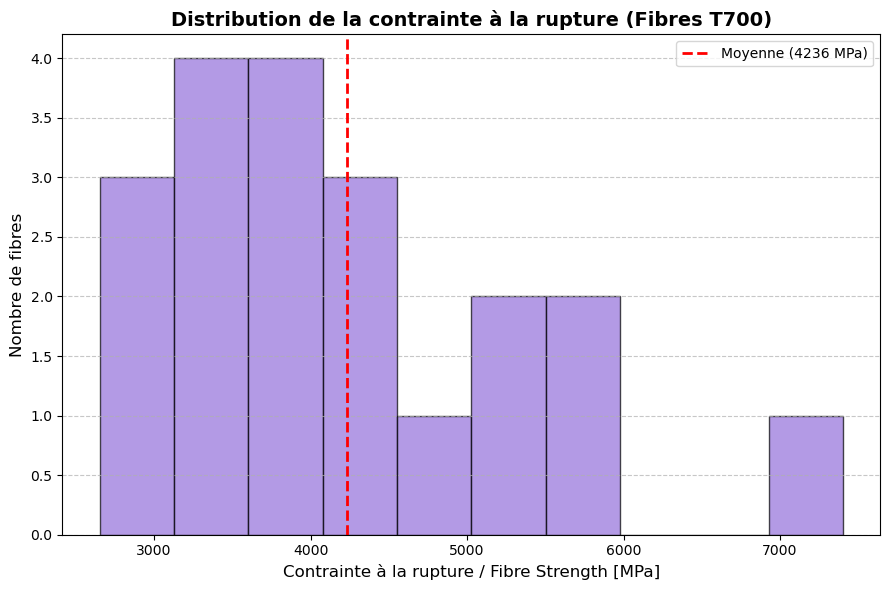

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('donnees_brutes_t700_diametre_contraintemax.csv')

# conversion du diamètre µm en mm
df['Diameter (mm)'] = df['Diameter (microns)'] / 1000

# Calcul de l'aire de la section en mm²
df['Area (mm2)'] = np.pi * (df['Diameter (mm)'] ** 2) / 4

# calcul de lacontrainte à la rupture en MPa
df['Fibre Strength (MPa)'] = df['Failure Load (N)'] / df['Area (mm2)']

strength = df['Fibre Strength (MPa)']

# analyse
moyenne = strength.mean()
ecart_type = strength.std()
minimum = strength.min()
maximum = strength.max()

print("\n--- Statistiques sur la contrainte à la rupture ---")
print(f"Nombre de fibres testées : {len(strength)}")
print(f"Moyenne : {moyenne:.0f} MPa")
print(f"Écart-type : {ecart_type:.0f} MPa")
print(f"Minimum : {minimum:.0f} MPa")
print(f"Maximum : {maximum:.0f} MPa")
print(f"Coefficient de variation (CV) : {(ecart_type/moyenne)*100:.1f} %")

# histogramme
plt.figure(figsize=(9, 6))
plt.hist(strength, bins=10, color='mediumpurple', edgecolor='black', alpha=0.7)

plt.axvline(moyenne, color='red', linestyle='dashed', linewidth=2, 
            label=f'Moyenne ({moyenne:.0f} MPa)')

plt.title("Distribution de la contrainte à la rupture (Fibres T700)", fontsize=14, fontweight='bold')
plt.xlabel("Contrainte à la rupture / Fibre Strength [MPa]", fontsize=12)
plt.ylabel("Nombre de fibres", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

Analyse

Image constructeur distribution + explication procédé de fabrication

### Conclusion :

Conclusion